CONCEPT OF UNSUPERVISED LEARNING
Unsupervised learning is a machine learning technique that works with data that has no labeled target variable. It identifies hidden patterns or groups within the data automatically. In this project, K-Means clustering groups customers based on similarities in annual income and spending score. Unlike supervised learning, which uses labeled data to predict known outcomes such as "good" or "bad" credit risk, unsupervised learning discovers patterns without predefined labels.

In [1]:
#import frameworks
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans

In [2]:
#load dataset
df=pd.read_csv("Mall_Customers.csv")
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [4]:
#select features and variables
x=df[['Annual Income (k$)','Spending Score (1-100)']]

In [8]:
import warnings
warnings.filterwarnings("ignore")

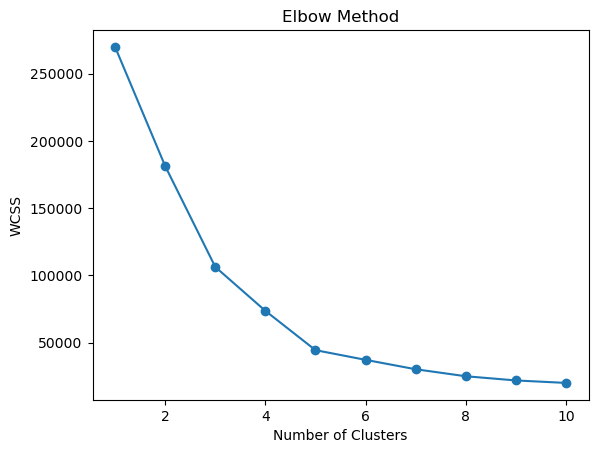

In [10]:
wcss=[]
for i in range(1,11):
    kmeans=KMeans(n_clusters=i,random_state=42,n_init=10)
    kmeans.fit(x)
    wcss.append(kmeans.inertia_)

plt.plot(range(1,11),wcss,marker='o')
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.show()

In [11]:
#apply kmeans
kmeans=KMeans(n_clusters=5,random_state=42,n_init=10)
df["Cluster"]=kmeans.fit_predict(x)

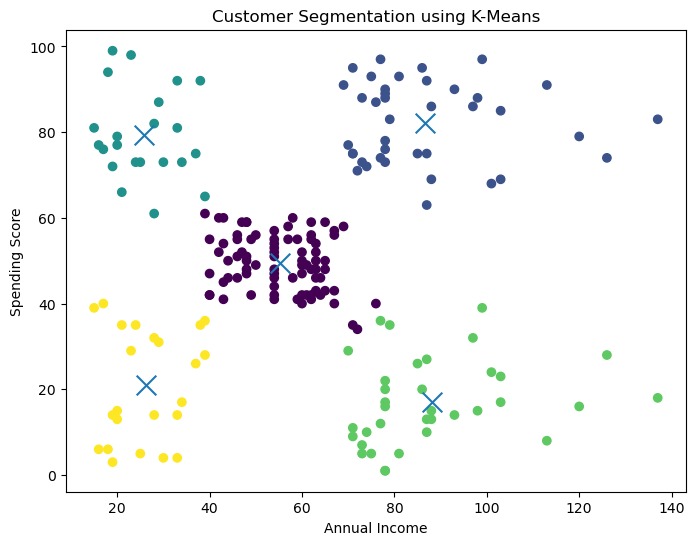

In [13]:
#plot the clusters
plt.figure(figsize=(8,6))
plt.scatter(
    x['Annual Income (k$)'],
    x['Spending Score (1-100)'],
    c=df["Cluster"])
plt.scatter(kmeans.cluster_centers_[:,0],
            kmeans.cluster_centers_[:,1],
            s=200,
            marker="x")
plt.xlabel("Annual Income")
plt.ylabel("Spending Score")
plt.title("Customer Segmentation using K-Means")
plt.show()

Cluster 0: High income, high spending (Premium customers)
Cluster 1: High income, low spending (Need targeted promotions)
Cluster 2: Low income, high spending (Frequent bargain shoppers)
Cluster 3: Low income, low spending (Low-value customers)
Cluster 4: Medium income, medium spending (Average customers)

BUSINESS STRATEGIES
High income & high spending = VIP rewards and exclusive offers.
High income & low spending = Personalized discounts to increase purchases.
Low income & high spending = Loyalty programs and coupons.

In [14]:
#prediction
new_customer=[[70,80]]
prediction=kmeans.predict(new_customer)
print("Cluster:",prediction[0])

Cluster: 1
